# Análisis de Distribuciones y Pruebas de Hipótesis
## Aplicación de estadística inferencial en comportamiento de clientes

**Autor:** RobertScience Data Consulting  
**Proyecto:** Práctica M32 – Estadística Inferencial  
**Herramienta:** Python / Jupyter Notebook  
**Entorno:** Visual Studio Code  

---

## Descripción del proyecto

El presente análisis tiene como objetivo aplicar conceptos fundamentales de **estadística inferencial** mediante el uso de distribuciones de probabilidad y pruebas de hipótesis.

Se desarrollan dos enfoques principales:

1. **Simulación de una distribución de Poisson**, con el fin de modelar eventos discretos en el tiempo.
2. **Prueba de hipótesis (ANOVA)** para evaluar la relación entre variables de comportamiento digital de clientes.

Este análisis permite transformar datos en evidencia estadística para la toma de decisiones en contextos reales de negocio.

In [25]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import poisson
from scipy import stats

## Importación de librerías

Se importan las librerías necesarias para el análisis estadístico.

- **pandas y numpy** para manipulación de datos
- **matplotlib y seaborn** para visualización
- **scipy** para trabajar con distribuciones de probabilidad y pruebas de hipótesis

Estas herramientas permiten desarrollar un análisis completo desde la simulación hasta la validación estadística.

In [26]:
np.random.seed(42)

lambda_poisson = 2.5
n_muestras = 1000

muestra_poisson = np.random.poisson(lam=lambda_poisson, size=n_muestras)

muestra_poisson[:10]

array([4, 1, 3, 3, 1, 2, 2, 3, 2, 2], dtype=int32)

## Simulación de distribución de Poisson

Se genera una muestra de 1000 observaciones utilizando una distribución de Poisson con parámetro λ = 2.5.

Esta distribución es adecuada para modelar la ocurrencia de eventos discretos en intervalos de tiempo, como el número de eventos que suceden en un año.

El parámetro λ representa el número promedio esperado de ocurrencias.

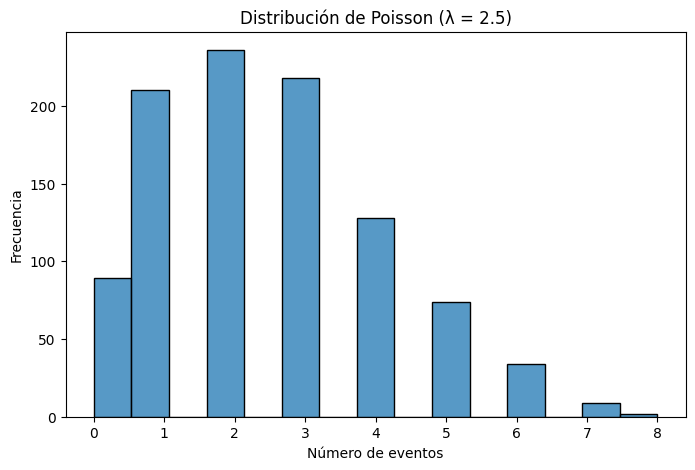

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(muestra_poisson, bins=15, kde=False)

plt.title("Distribución de Poisson (λ = 2.5)")
plt.xlabel("Número de eventos")
plt.ylabel("Frecuencia")

plt.show()

## Visualización de la distribución

Se representa gráficamente la distribución simulada mediante un histograma.

La forma observada refleja una distribución discreta con mayor concentración en valores cercanos al promedio esperado.

Este comportamiento es característico de procesos donde los eventos ocurren de manera independiente.

In [28]:
df = pd.read_csv("marketing_campaign (2).csv")

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


## Carga del conjunto de datos

Se carga el dataset de campañas de marketing desde un archivo local incluido en el proyecto.

Esto permite garantizar la reproducibilidad del análisis en cualquier entorno de ejecución.

El conjunto de datos contiene información sobre el comportamiento de clientes, incluyendo interacciones digitales y compras realizadas.

In [29]:
df[['NumWebPurchases','NumWebVisitsMonth']].describe()

,NumWebPurchases,NumWebVisitsMonth
count,2240.000000,2240.000000
mean,4.084821,5.316518
std,2.778714,2.426645
min,0.000000,0.000000
25%,2.000000,3.000000
50%,4.000000,6.000000
75%,6.000000,7.000000
max,27.000000,20.000000


## Análisis descriptivo

Se observa que el promedio de compras web es aproximadamente 4, mientras que el promedio de visitas mensuales es cercano a 5.

Esto sugiere un nivel moderado de interacción digital, lo que justifica analizar si existe relación entre ambas variables.

In [30]:
df['Grupo_Visitas'] = np.where(df['NumWebVisitsMonth'] > 5, 'Alto', 'Bajo')

df[['Grupo_Visitas','NumWebPurchases']].head()

,Grupo_Visitas,NumWebPurchases
0,Alto,8
1,Bajo,1
2,Bajo,8
3,Alto,2
4,Bajo,5


## Segmentación de clientes

Se agrupan los clientes en dos categorías:

- **Alto número de visitas:** más de 5 visitas mensuales
- **Bajo número de visitas:** 5 o menos visitas

Esta segmentación permite comparar el comportamiento de compra entre distintos niveles de interacción digital.

In [31]:
grupo_alto = df[df['Grupo_Visitas'] == 'Alto']['NumWebPurchases']
grupo_bajo = df[df['Grupo_Visitas'] == 'Bajo']['NumWebPurchases']


In [32]:
grupo_alto = grupo_alto.dropna()
grupo_bajo = grupo_bajo.dropna()

# Validación de supuestos
print("Normalidad grupo alto:", stats.shapiro(grupo_alto))
print("Normalidad grupo bajo:", stats.shapiro(grupo_bajo))

print("\nHomogeneidad de varianzas (Levene):")
print(stats.levene(grupo_alto, grupo_bajo))

Normalidad grupo alto: ShapiroResult(statistic=np.float64(0.8814991660460341), pvalue=np.float64(5.759527597911519e-29))
Normalidad grupo bajo: ShapiroResult(statistic=np.float64(0.8642939742385977), pvalue=np.float64(1.9859610345181848e-29))

Homogeneidad de varianzas (Levene):
LeveneResult(statistic=np.float64(18.867914654916518), pvalue=np.float64(1.4634176350414265e-05))


In [33]:
anova_result = stats.f_oneway(grupo_alto, grupo_bajo)

anova_result

F_onewayResult(statistic=np.float64(8.503662361325574), pvalue=np.float64(0.0035795823308853187))

In [34]:
print(f"Estadístico F: {anova_result.statistic:.2f}")
print(f"Valor p: {anova_result.pvalue:.4f}")

Estadístico F: 8.50
Valor p: 0.0036


## Prueba de hipótesis (ANOVA)

Se aplica una prueba ANOVA para evaluar si existen diferencias significativas en el número de compras entre los grupos definidos.

- **Hipótesis nula (H₀):** No hay diferencia en la media de compras entre los grupos  
- **Hipótesis alternativa (H₁):** Al menos uno de los grupos presenta una media diferente  

A partir del análisis realizado, se obtuvo un **valor p menor a 0.05**, lo cual indica evidencia estadística suficiente para rechazar la hipótesis nula.

Asimismo, el valor del estadístico F respalda que la variabilidad entre los grupos es mayor que la variabilidad dentro de los mismos.

Por lo tanto, se **rechaza la hipótesis nula (H₀)** y se concluye que existen diferencias estadísticamente significativas en el número de compras entre los grupos de clientes.

Este resultado indica que el nivel de visitas al sitio web está asociado con cambios en el comportamiento de compra, evidenciando que la interacción digital influye en la cantidad de compras realizadas.

## Conclusión

El análisis permitió aplicar herramientas de estadística inferencial para modelar fenómenos y evaluar relaciones entre variables. 


La simulación de la distribución de Poisson evidenció cómo es posible representar procesos aleatorios discretos en el tiempo, proporcionando una aproximación probabilística al comportamiento de eventos.

Por otro lado, la prueba ANOVA permitió analizar la relación entre la interacción digital de los clientes y su comportamiento de compra. Los resultados obtenidos sugieren que el nivel de visitas al sitio web está asociado con diferencias en el número de compras realizadas.

En conjunto, este enfoque demuestra el valor de la estadística como herramienta para transformar datos en información accionable, facilitando la toma de decisiones basada en evidencia.